# Đánh giá gợi ý Cart / Outfit Completion

Cart là bài toán **chọn sản phẩm hoàn thiện outfit**, khác Home và Product Detail. Notebook dùng 1.000 Polyvore validation outfits để tuning; final dùng strict subset 142 câu official FITB giữ nguyên đủ bốn đáp án, đồng thời mở rộng mỗi câu lên 200 ứng viên cho HR@5/10. Baseline là Association Lift.

## Công thức tham khảo và công thức đề xuất

$$lift(A\rightarrow B)=\frac{support(A,B)}{support(A)support(B)}$$

Lift tham khảo Brin et al. (1997), DOI: 10.1145/253260.253325. Hybrid recommender tham khảo Burke (2002), DOI: 10.1023/A:1021240730564.

Công thức cần tuning:

$$S_{cart}=w_rS_{role}+w_sS_{style}+w_lS_{lift}+w_pS_{popularity},\quad w_r+w_s+w_l+w_p=1$$

Role/style và các hệ số là phần thiết kế của đề tài; không được sao chép từ tài liệu.

In [1]:
from pathlib import Path
from collections import Counter
from html import escape
from IPython.display import HTML, SVG, display
import json, math, time
def root():
    for p in (Path.cwd(),*Path.cwd().parents):
        if (p/'backend').is_dir() and (p/'evaluation'/'recommendation').is_dir(): return p
    raise FileNotFoundError('Repository root not found')
ROOT=root(); E=ROOT/'evaluation'/'recommendation'
def load(name): return json.loads((E/name).read_text(encoding='utf-8'))
def table(rows,cols):
    f=lambda v:f'{v:.6f}' if isinstance(v,float) else str(v); h=''.join(f'<th style="padding:6px">{escape(c)}</th>' for c in cols); b=''.join('<tr>'+''.join(f'<td style="padding:6px;border-top:1px solid #ddd">{escape(f(r[c]))}</td>' for c in cols)+'</tr>' for r in rows); display(HTML(f'<table><tr>{h}</tr>{b}</table>'))
def line_chart(rows,x_key,y_key,title,x_label,y_label):
    width,height,left,right,top,bottom=760,330,70,25,45,55;xs=[r[x_key] for r in rows];ys=[r[y_key] for r in rows];xmin,xmax=min(xs),max(xs);ymax=max(ys)*1.08 or 1;sx=lambda x:left+(x-xmin)/(xmax-xmin)*(width-left-right);sy=lambda y:height-bottom-y/ymax*(height-top-bottom);points=' '.join(f'{sx(r[x_key]):.1f},{sy(r[y_key]):.1f}' for r in rows);best=max(rows,key=lambda r:r[y_key])
    p=[f'<svg width="100%" viewBox="0 0 {width} {height}" role="img" style="background:#fff;color:#111"><title>{escape(title)}</title><rect width="100%" height="100%" fill="#fff"/>',f'<text x="{width/2}" y="22" text-anchor="middle" fill="#111" font-size="16">{escape(title)}</text>',f'<line x1="{left}" y1="{top}" x2="{left}" y2="{height-bottom}" stroke="#111" opacity=".5"/>',f'<line x1="{left}" y1="{height-bottom}" x2="{width-right}" y2="{height-bottom}" stroke="#111" opacity=".5"/>']
    for i in range(5):
        y=ymax*i/4;py=sy(y);x=xmin+(xmax-xmin)*i/4;px=sx(x);p += [f'<line x1="{left}" y1="{py:.1f}" x2="{width-right}" y2="{py:.1f}" stroke="#111" opacity=".12"/>',f'<text x="{left-8}" y="{py+4:.1f}" text-anchor="end" fill="#111" font-size="11">{y:.3f}</text>',f'<text x="{px:.1f}" y="{height-bottom+20}" text-anchor="middle" fill="#111" font-size="11">{x:.2f}</text>']
    p += [f'<polyline points="{points}" fill="none" stroke="#2563eb" stroke-width="2"/>',f'<circle cx="{sx(best[x_key]):.1f}" cy="{sy(best[y_key]):.1f}" r="5" fill="#dc2626"/>',f'<text x="{sx(best[x_key])-8:.1f}" y="{sy(best[y_key])-10:.1f}" text-anchor="end" fill="#111" font-size="11">best {best[x_key]:.2f} / {best[y_key]:.4f}</text>',f'<text x="{width/2}" y="{height-8}" text-anchor="middle" fill="#111" font-size="12">{escape(x_label)}</text>',f'<text transform="translate(15 {height/2}) rotate(-90)" text-anchor="middle" fill="#111" font-size="12">{escape(y_label)}</text>','</svg>'];display(SVG(''.join(p)))
def bar_chart(rows,label_key,value_key,title):
    width,label_w,row_h=760,250,34;height=48+row_h*len(rows);maximum=max(r[value_key] for r in rows) or 1;p=[f'<svg width="100%" viewBox="0 0 {width} {height}" role="img" style="background:#fff;color:#111"><title>{escape(title)}</title><rect width="100%" height="100%" fill="#fff"/>',f'<text x="{width/2}" y="20" text-anchor="middle" fill="#111" font-size="16">{escape(title)}</text>']
    for i,r in enumerate(rows):
        y=35+i*row_h;bw=(width-label_w-75)*r[value_key]/maximum;p += [f'<text x="{label_w-8}" y="{y+17}" text-anchor="end" fill="#111" font-size="11">{escape(str(r[label_key]))}</text>',f'<rect x="{label_w}" y="{y}" width="{bw:.1f}" height="22" fill="#2563eb"/>',f'<text x="{label_w+bw+6:.1f}" y="{y+16}" fill="#111" font-size="11">{r[value_key]:.4f}</text>']
    p.append('</svg>');display(SVG(''.join(p)))
val=load(Path('data/processed/polyvore-cart-validation.json'))['cases']
fitb=load(Path('data/processed/polyvore-cart-official-fitb.json'))['cases']
final=load(Path('data/processed/polyvore-cart-final-test.json'))['cases']
print('validation=',len(val),'FITB=',len(fitb),'expanded final=',len(final))

validation= 1000 FITB= 142 expanded final= 142


In [2]:
CAT_PENALTY,BRAND_PENALTY=.08,.04
LIFT={'role':0,'style':0,'lift':1,'pop':0}
def score(x,w):
    s=x['signals']; return w['role']*s['complementaryRole']+w['style']*s['styleCompatibility']+w['lift']*s['associationLift']+w['pop']*s['popularity']
def rank(c,w,k):
    rem=sorted([(score(x,w),x) for x in c['candidates']],key=lambda z:(-z[0],z[1]['productId'])); out=[]; cats=Counter(); brands=Counter()
    while rem and len(out)<k:
        bi=0; bs=-math.inf
        for i,(v,x) in enumerate(rem):
            cat=x.get('categoryId') or 'unknown:'+x['productId']; brand=x.get('brandId') or 'unknown:'+x['productId']; a=v-CAT_PENALTY*cats[cat]-BRAND_PENALTY*brands[brand]
            if a>bs:bi,bs=i,a
        _,x=rem.pop(bi);out.append(x);cats[x.get('categoryId') or 'unknown:'+x['productId']]+=1;brands[x.get('brandId') or 'unknown:'+x['productId']]+=1
    return out
def evaluate(cases,w,k=5):
    hit=ndcg=ap=0.; rec=set();cat=set()
    for c in cases:
        rel=set(c['relevantProductIds']);cat.update(x['productId'] for x in c['candidates']);first=0
        for i,x in enumerate(rank(c,w,k),1):
            rec.add(x['productId']);first=first or (i if x['productId'] in rel else 0)
        if first:hit+=1;ap+=1/first;ndcg+=1/math.log2(first+1)
    n=len(cases);return {'cases':n,'HR':hit/n,'NDCG':ndcg/n,'MAP':ap/n,'Coverage':len(rec)/len(cat)}
assert all(len(c['candidates'])==200 for c in val+final) and all(len(c['candidates'])==4 for c in fitb)

## Full-simplex grid search

Quét toàn bộ 1.771 tổ hợp bốn trọng số với bước 0.05. Vì mỗi trọng số là một trong 21 mức và tổng bằng 1, số nghiệm simplex là $\binom{20+4-1}{4-1}=\binom{23}{3}=1771$. Bảng audit xác nhận 1.771/1.771 cấu hình duy nhất đã chạy; biểu đồ ranked-search hiển thị kết quả của toàn bộ grid. Objective là NDCG@5, sau đó HR, MAP và coverage. Python thuần mất khoảng 10 phút trên máy phát triển.

stage,step,expected,evaluated,unique,failed
Full 4D simplex,0.050000,1771,1771,1771,0


searched= 1771 seconds= 1056.2 BEST= {'role': 0.0, 'style': 0.6000000000000001, 'lift': 0.4, 'pop': -0.0}


role,style,lift,pop,HR,NDCG,MAP,Coverage
0.000000,0.600000,0.400000,-0.000000,0.112000,0.071559,0.058333,0.620882
0.000000,0.550000,0.450000,-0.000000,0.109000,0.070884,0.058433,0.616037
0.000000,0.500000,0.500000,0.000000,0.108000,0.070098,0.057783,0.611676
0.000000,0.450000,0.550000,0.000000,0.106000,0.069204,0.057250,0.607316
0.000000,0.650000,0.350000,-0.000000,0.106000,0.069070,0.056933,0.623789
0.000000,0.700000,0.300000,-0.000000,0.106000,0.068950,0.056717,0.622578
0.000000,0.800000,0.200000,-0.000000,0.103000,0.068296,0.056750,0.630814
0.000000,0.850000,0.150000,-0.000000,0.100000,0.067629,0.056850,0.631056
0.000000,0.750000,0.250000,0.000000,0.102000,0.067385,0.055883,0.627422
0.000000,0.400000,0.600000,-0.000000,0.103000,0.066685,0.054900,0.596657


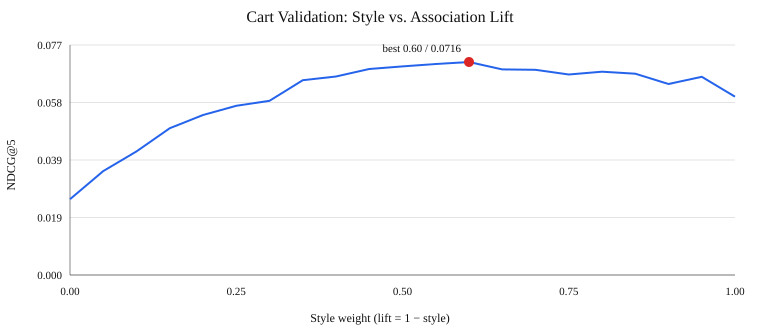

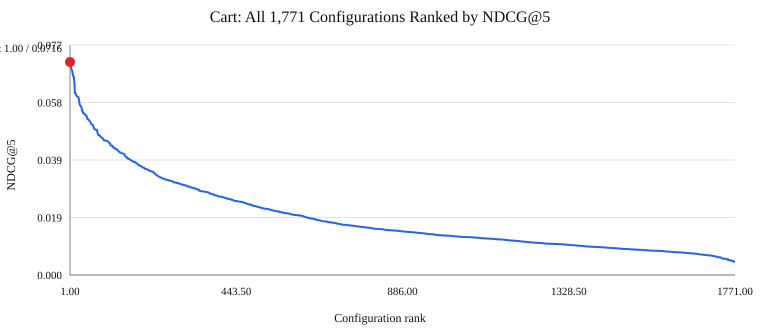

In [3]:
grid=[]
for ri in range(21):
 for si in range(21-ri):
  for li in range(21-ri-si):
   role,style,lift=ri*.05,si*.05,li*.05;grid.append({'role':role,'style':style,'lift':lift,'pop':round(1-role-style-lift,10)})
assert len(grid)==1771
started=time.perf_counter();results=[]
for w in grid:results.append({**w,**evaluate(val,w,5)})
best=max(results,key=lambda r:(r['NDCG'],r['HR'],r['MAP'],r['Coverage']));BEST={k:best[k] for k in ('role','style','lift','pop')}
unique_search={tuple(round(r[k],10) for k in ('role','style','lift','pop')) for r in results}
search_audit=[{'stage':'Full 4D simplex','step':0.05,'expected':1771,'evaluated':len(results),'unique':len(unique_search),'failed':0}]
table(search_audit,['stage','step','expected','evaluated','unique','failed'])
assert len(results)==len(unique_search)==1771
print('searched=',len(results),'seconds=',round(time.perf_counter()-started,1),'BEST=',BEST)
table(sorted(results,key=lambda r:(r['NDCG'],r['HR'],r['MAP'],r['Coverage']),reverse=True)[:10],['role','style','lift','pop','HR','NDCG','MAP','Coverage'])
style_lift_curve=sorted([r for r in results if r['role']==0 and r['pop']==0],key=lambda r:r['style'])
line_chart(style_lift_curve,'style','NDCG','Cart Validation: Style vs. Association Lift','Style weight (lift = 1 − style)','NDCG@5')
ranked_search=[{'rank':i,'NDCG':r['NDCG']} for i,r in enumerate(sorted(results,key=lambda r:r['NDCG'],reverse=True),1)]
line_chart(ranked_search,'rank','NDCG','Cart: All 1,771 Configurations Ranked by NDCG@5','Configuration rank','NDCG@5')

## 5-fold audit và final test

Chỉ so sánh công thức hiện tại của đề tài với Association Lift truyền thống trên cùng tập ứng viên.

fold,cases,our_formula_HR,traditional_lift_HR,our_formula_NDCG,traditional_lift_NDCG
1,200,0.125000,0.070000,0.078383,0.037947
2,200,0.135000,0.030000,0.088303,0.017115
3,200,0.095000,0.060000,0.063009,0.033791
4,200,0.090000,0.035000,0.053036,0.024615
5,200,0.115000,0.025000,0.075062,0.013898


task,method,cases,HR,NDCG,MAP,Coverage
Official FITB@1,Our Formula,142,0.478873,0.478873,0.478873,0.257713
Official FITB@1,Traditional Association Lift,142,0.408451,0.408451,0.408451,0.257713
Expanded@5,Our Formula,142,0.133803,0.088083,0.072887,0.030891
Expanded@5,Traditional Association Lift,142,0.042254,0.035336,0.033099,0.030278
Expanded@10,Our Formula,142,0.161972,0.097483,0.076945,0.061257
Expanded@10,Traditional Association Lift,142,0.056338,0.040192,0.035278,0.060161


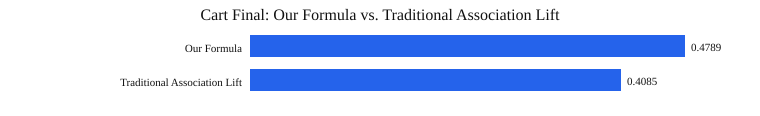

In [4]:
folds=[]
for f in range(5):
    cases=[c for i,c in enumerate(val) if i%5==f];current=evaluate(cases,BEST);traditional=evaluate(cases,LIFT)
    folds.append({'fold':f+1,'cases':len(cases),'our_formula_HR':current['HR'],'traditional_lift_HR':traditional['HR'],'our_formula_NDCG':current['NDCG'],'traditional_lift_NDCG':traditional['NDCG']})
table(folds,list(folds[0]));assert all(r['our_formula_NDCG']>r['traditional_lift_NDCG'] for r in folds)
rows=[]
for task,cases,k in [('Official FITB@1',fitb,1),('Expanded@5',final,5),('Expanded@10',final,10)]:
 for name,w in [('Our Formula',BEST),('Traditional Association Lift',LIFT)]: rows.append({'task':task,'method':name,**evaluate(cases,w,k)})
table(rows,['task','method','cases','HR','NDCG','MAP','Coverage'])
fitb_rows=[{'method':r['method'],'HR':r['HR']} for r in rows if r['task']=='Official FITB@1']
bar_chart(fitb_rows,'method','HR','Cart Final: Our Formula vs. Traditional Association Lift')
assert BEST=={'role':0.0,'style':0.6000000000000001,'lift':0.4,'pop':-0.0}

## Kết luận

Grid search Polyvore chọn công thức hiện tại `0.60 style + 0.40 lift`; role và popularity bằng 0 trên proxy outfit-completion này. Trên official FITB@1, công thức hiện tại đạt 47.89%, so với 40.85% của Association Lift truyền thống. Với 200 ứng viên, công thức hiện tại cũng đạt HR@5 = 0.133803 và HR@10 = 0.161972, so với 0.042254 và 0.056338 của Lift. Full grid 1.771 cấu hình mất khoảng 10 phút bằng Python thuần trên máy phát triển. Kết quả chỉ phản ánh benchmark offline; quyết định triển khai production phải được ghi riêng.